# Run a VCell PDE simulation from solver input files
1. Copy all files from solver_input directory to a temporary directory for solving
2. prepare empty solver output directory, copying in the functions file
2. Execute the Finite Volume PDE solver

### In this example, we are using the Model instance as an example, as the get input files endpoint is not yet implemented.

In [1]:
from pathlib import Path
import tempfile
import shutil
import os

from pyvcell.data_model.simulation import SpatialSimulation
from pyvcell.data_model.spatial_model import SpatialModel


def get_temp_solver_dir(solver_input_dir: Path, temp_dir_prefix: str = None) -> Path:
    # prepare input dir
    temp_solver_dir = Path(tempfile.mkdtemp(prefix=temp_dir_prefix or 'pyvcell_test_data_'))
    for file in solver_input_dir.iterdir():
        shutil.copy(file, temp_solver_dir)

    return temp_solver_dir


def prepare_output_dir(solver_output_dir: Path, functions_file: Path) -> None:
    # prepare output dir: clear contents of solver_output_dir
    for file in solver_output_dir.iterdir():
        if file.is_file() and not file.name.startswith('.'):
            file.unlink()

    # copy functions file to solver_output_dir
    shutil.copy(functions_file, solver_output_dir)


# define input dir, output_dir and spatial model
solver_input_dir = Path(os.getcwd()) / "solver_input"
temp_solver_dir = get_temp_solver_dir(solver_input_dir)
functions_file = temp_solver_dir / "SimID_946368938_0_.functions"

solver_output_dir = Path(os.getcwd()) / "test_output"

model_fp = os.path.join(solver_input_dir, "all.xml")

# define editable spatial model and simulation instances
model = SpatialModel(filepath=model_fp)
simulation = SpatialSimulation(model=model, input_dir_path=solver_input_dir, output_dir_path=solver_output_dir, functions_file=functions_file)

# TODO: replace below with simulation.get_input_files()
fv_input_file = temp_solver_dir / "SimID_946368938_0_.fvinput"
vcg_file = temp_solver_dir / "SimID_946368938_0_.vcg"

In [2]:
job_id = 0
sim_id = 946368938
result = simulation.run(fv_input_file=fv_input_file, vcg_input_file=vcg_file, solver_output_dir=solver_output_dir, sim_id=sim_id, job_id=job_id)

initializing mesh
numVolume=126025

CartesianMesh::computeNormalsFromNeighbors(), compute normals from neighbors
Membrane Elements -> N=7817
--------Num of points that have zero neighbors 0
--------Num Neighbors before symmetrize 46161
--------Num Neighbors after symmetrize 51016
Total volume=5824.650822
Total FluxArea =36.79383373
Total FluxAreaXM =0
Total FluxAreaXP =0
Total FluxAreaYM =21.43445916
Total FluxAreaYP =15.35937457
Total FluxAreaZM =0
Total FluxAreaZP =0
mesh initialized
preprocessing finished
pdeCount=4, odeCount=0
error opening log file </Users/alexanderpatrie/Desktop/repos/pyvcell/examples/test_output/SimID_946368938_0_.log>
simulation [SimID_946368938_0_] started
temporary directory used is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/
sim file name is /var/folders/yy/8crj8x7x5_3b86f0js6_0bn00000gr/T/SimID_946368938_0_0000.sim
**This is a little endian machine.**
[[[data:0]]]
numVolRegions=6
Region 0: size=110800, offset=0
Region 1: size=12207, offset=110800
Regi

Simulation Complete in Main() ... 


In [3]:
channel_index = 2
z_index = 9
time_index = 3

result.plot_slice_2d(time_index, channel_index, z_index)

AttributeError: 'Result' object has no attribute 'get_metadata'

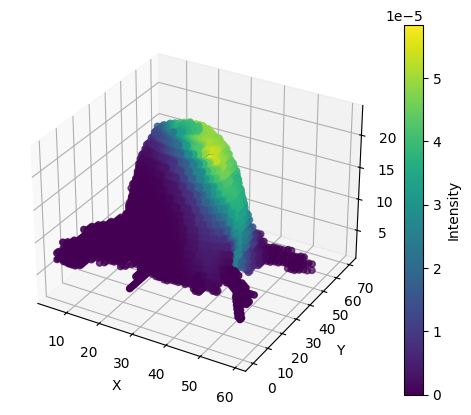

In [4]:
result.plot_slice_3d(time_index, channel_index)

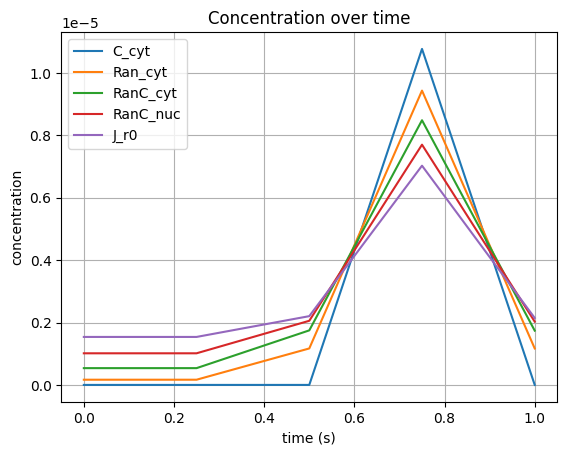

In [5]:
result.plot_concentrations()

## extract the vcell simulation dataset from the tarball (compressed to save space)

## read vcell simulation results metadata
* `PdeDataSet` contains the metadata for the tabular simulation results (e.g. state variables, shape, time points)
* `DataFunctions` contains the function definitions (name, expression, type, domain)
![vcell simulation results](./example_vcell_ui.png)

## write the vcell simulation dataset to zarr including:
* metadata
* numerical datasets from stored data and evaluated functions
* ... masks for domains coming soon (e.g. cell, extracellular, etc.)

## Open and display slices from the zarr dataset as an image
* no masking for domains
* different colormap and scaling

## Open and display slices from the post processing dataset as an image

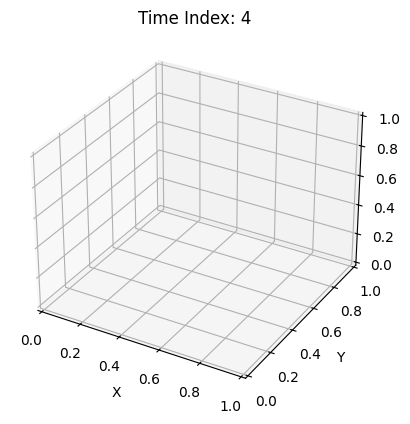

In [6]:
from IPython.display import HTML

result.render_3d_slice_animation(channel_index)

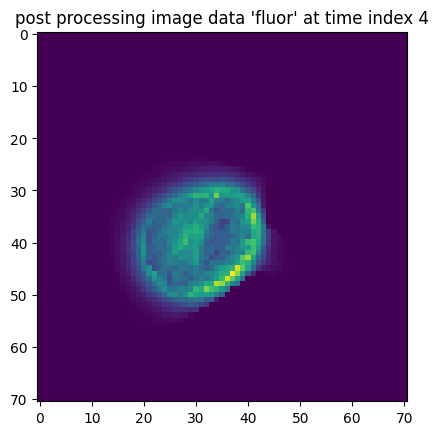

In [6]:
import numpy as np
from matplotlib import pyplot as plt

post_processing = result.get_post_processing()
# display image dataset "fluor" at time index 4 as an image
fluorescence = post_processing.image_metadata[0]
image_data: np.ndarray = post_processing.read_image_data(image_metadata=fluorescence, time_index=4)
plt.imshow(image_data)
plt.title("post processing image data 'fluor' at time index 4")
plt.show()

## Open and display Variable Statistics from the post processing dataset

In [21]:
post_processing.variables[0].stat_var_unit

'uM'

list

pyvcell.simdata.postprocessing.VariableInfo

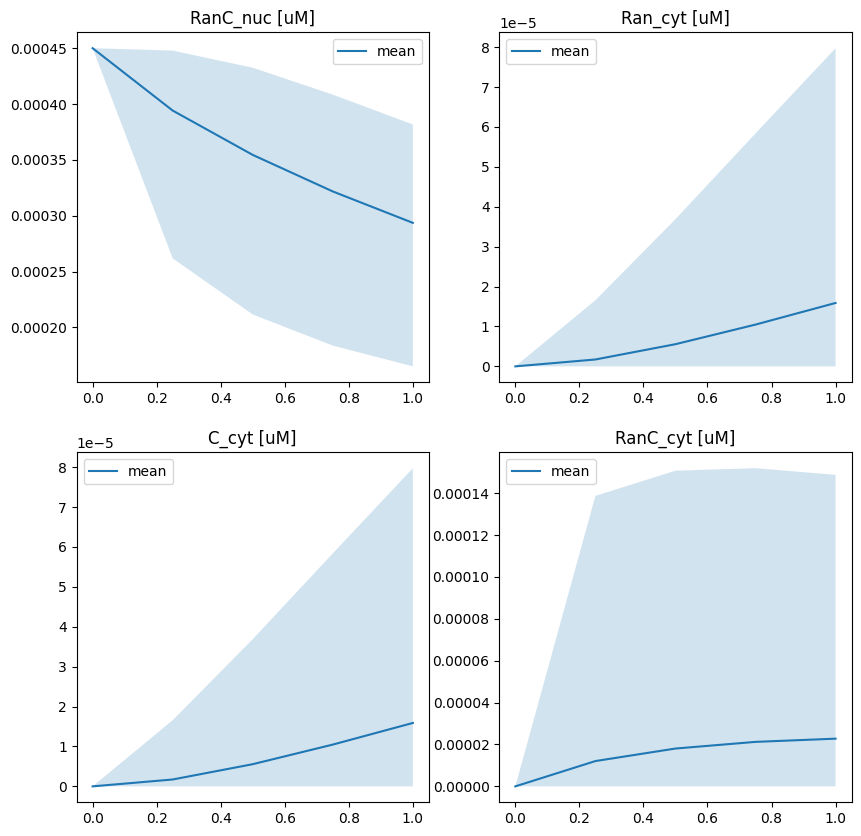

In [11]:
var_averages = list(set([var for var in post_processing.variables if var.statistic_type == 0]))
display(type(var_averages))
display(type(var_averages[0]))
series_arrays = []
series_legend = []
times = post_processing.times
# add envelope plot for each variable
for var_average in var_averages:
    series_arrays.append(post_processing.statistics[:,var_average.var_index,[0,2,3]])
    series_legend.append(f"{var_average.var_name} [{var_average.stat_var_unit}]")

# each series_array has 3 columns: mean, min, max
# plot each series on a different plot arranged in a 2x2 grid with a legend from series_legends
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for i, series_array in enumerate(series_arrays):
    ax[int(i/2), i%2].plot(times, series_array[:,0], label='mean')
    ax[int(i/2), i%2].fill_between(times, series_array[:,1], series_array[:,2], alpha=0.2)
    ax[int(i/2), i%2].set_title(series_legend[i])
    ax[int(i/2), i%2].legend()